# Sensitivity of normative network topology

Regularization sensitivity and control-subject subsampling of an FDG-PET graphical-lasso network. Comparisons include:
- edge agreement
- density
- connectivity
- frequency-based consensus.

In [1]:
from pathlib import Path
import json
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from IPython.display import Markdown, display

ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / 'data/processed/suvr/20251130_suvr.parquet').is_file()
)
SUVR_PATH = ROOT / 'data/processed/suvr/20251130_suvr.parquet'
REFERENCE_PATH = ROOT / 'data/processed/graphical_lasso/connectivity_matrix_lambda_0.06.parquet'

LAMBDA = 0.060
LAMBDA_GRID = np.array([0.040, 0.050, 0.055, 0.060, 0.065, 0.070, 0.080])
SELECTION_GRID = np.array([
    0.001, 0.005, 0.010, 0.020, 0.030, 0.040, 0.050, 0.060, 0.070, 0.080,
    0.090, 0.100, 0.200, 0.300, 0.400, 0.500, 0.600, 0.700, 0.800, 0.900,
])
SEED = 20260930
REPETITIONS = 1000
RETAINED_FRACTION = 0.85
CONSENSUS_THRESHOLD = 0.80
FREQUENCY_THRESHOLDS = np.array([0.50, 0.70, 0.80, 0.90])

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
})
BLUE, ORANGE = '#34688a', '#b77842'

## Data processing

In [ ]:
data = pd.read_parquet(SUVR_PATH)
suvr_columns = [column for column in data if column.endswith('suvr')]
values = data[suvr_columns].to_numpy(dtype=float)

fit_rois = [
    column for column in suvr_columns
    if not ('cereb' in column.lower() or 'vermis' in column.lower())
]
control_groups = ['controls', 'controls-adni']
controls = data.loc[data.group.isin(control_groups), fit_rois]
reference = pd.read_parquet(REFERENCE_PATH)

n, p = controls.shape
roi_names = reference.index.to_numpy(dtype=str)
u, v = np.triu_indices(p, k=1)
possible_edges = len(u)
reference_edges = reference.to_numpy()[u, v].astype(bool)

# Fit in SUVR column order; compare in reference ROI order.
roi_order = np.array([fit_rois.index(roi) for roi in roi_names])
pair_indices = np.column_stack([roi_order[u] + 1, roi_order[v] + 1])
sample_size = int(round(RETAINED_FRACTION * n))
rng = np.random.default_rng(SEED)
sample_indices = np.stack([
    np.sort(rng.choice(n, size=sample_size, replace=False))
    for _ in range(REPETITIONS)
])

control_counts = pd.DataFrame({
    'Group': ['HCSC controls', 'ADNI controls'],
    'Included': [int((data.group == group).sum()) for group in control_groups],
})
display(control_counts.style.hide(axis='index'))

Group,Included
HCSC controls,35
ADNI controls,40


In [3]:
r_code = r"""
library(glasso)
library(jsonlite)
input <- fromJSON(paste(readLines(file("stdin"), warn = FALSE), collapse = "\n"))
X <- input$x
pairs <- input$pairs

covariance <- function(x) {
    stopifnot(all(is.finite(x)), all(apply(x, 2L, sd) > 0))
    s <- cov(scale(x, center = TRUE, scale = TRUE))
    (s + t(s)) / 2
}

fit_model <- function(s, lambda, maxit = 1000L) {
    fit <- glasso(s, rho = lambda, thr = 1e-4, maxit = maxit,
                  approx = FALSE, penalize.diagonal = TRUE, start = "cold")
    stopifnot(fit$errflag == 0L, fit$niter < maxit, all(is.finite(fit$wi)))
    fit
}

support <- function(fit) {
    a <- 1L * (abs(fit$wi) > 1e-6)
    diag(a) <- 0L
    a
}

s <- covariance(X)
criteria <- vapply(input$selection_grid, function(lambda) {
    fit <- fit_model(s, lambda, maxit = 10000L)
    e <- sum(support(fit)) / 2
    log_likelihood <- nrow(X) / 2 *
        (log(det(fit$wi)) - sum(diag(s %*% fit$wi)))
    -2 * log_likelihood + e * log(nrow(X)) + e * log(ncol(X))
}, numeric(1))
stopifnot(all(is.finite(criteria)))

grid_size <- length(input$grid)
repetitions <- nrow(input$indices)
masks <- matrix(0L, grid_size + repetitions, nrow(pairs))
iterations <- integer(nrow(masks))
asymmetric_pairs <- integer(nrow(masks))
for (i in seq_len(nrow(masks))) {
    if (i <= grid_size) {
        fit <- fit_model(s, input$grid[i])
    } else {
        rows <- input$indices[i - grid_size, ]
        stopifnot(length(unique(rows)) == length(rows),
                  all(rows >= 1L), all(rows <= nrow(X)))
        fit <- fit_model(covariance(X[rows, , drop = FALSE]), input$lambda)
    }
    a <- support(fit)
    masks[i, ] <- a[pairs]
    iterations[i] <- fit$niter
    asymmetric_pairs[i] <- sum(a[upper.tri(a)] != t(a)[upper.tri(a)])
}
cat(toJSON(list(masks = masks, criteria = criteria, iterations = iterations,
    asymmetric_pairs = asymmetric_pairs, r_version = as.character(getRversion()),
    glasso_version = as.character(packageVersion("glasso"))),
    auto_unbox = TRUE, digits = 17))
"""

payload = {
    'x': controls.to_numpy(dtype=float).tolist(),
    'pairs': pair_indices.tolist(),
    'selection_grid': SELECTION_GRID.tolist(),
    'grid': LAMBDA_GRID.tolist(),
    'indices': (sample_indices + 1).tolist(),
    'lambda': LAMBDA,
}
environment = os.environ.copy()
environment.update({
    'OPENBLAS_NUM_THREADS': '1', 'OMP_NUM_THREADS': '1', 'MKL_NUM_THREADS': '1',
})
completed = subprocess.run(
    ['Rscript', '--vanilla', '-e', r_code],
    input=json.dumps(payload, allow_nan=False), capture_output=True,
    text=True, env=environment,
)
if completed.returncode:
    raise RuntimeError(completed.stderr.strip() or completed.stdout.strip())
if completed.stderr.strip():
    raise RuntimeError(completed.stderr.strip())

fitted = json.loads(completed.stdout)
masks = np.asarray(fitted['masks'], dtype=np.uint8)
assert masks.shape == (len(LAMBDA_GRID) + REPETITIONS, possible_edges)
assert np.isin(masks, [0, 1]).all()
grid_masks = masks[:len(LAMBDA_GRID)].astype(bool)
subsample_masks = masks[len(LAMBDA_GRID):].astype(bool)
selection_scores = np.asarray(fitted['criteria'], dtype=float)
assert np.isfinite(selection_scores).all()
assert SELECTION_GRID[selection_scores.argmin()] == LAMBDA
assert np.array_equal(grid_masks[np.flatnonzero(LAMBDA_GRID == LAMBDA)[0]], reference_edges)


def graph_metrics(edges):
    adjacency = np.zeros((p, p), dtype=bool)
    adjacency[u, v] = edges
    adjacency[v, u] = edges
    edge_count = int(edges.sum())
    union = np.count_nonzero(edges | reference_edges)
    return {
        'edges': edge_count,
        'density': edge_count / possible_edges,
        'components': int(connected_components(
            csr_matrix(adjacency), directed=False, return_labels=False,
        )),
        'jaccard': np.count_nonzero(edges & reference_edges) / union if union else 1.0,
    }


reference_metrics = graph_metrics(reference_edges)
display(Markdown(
    f"The reference includes **{n} controls and {p} ROIs**, with "
    f"**{reference_metrics['edges']} edges** among {possible_edges:,} possible pairs "
    f"(density {100 * reference_metrics['density']:.2f}%; "
    f"mean degree {2 * reference_metrics['edges'] / p:.1f}; "
    f"{reference_metrics['components']} connected component). "
    f"The selection criterion identifies λ = {LAMBDA:.3f}, and its fitted edge set "
    f"reproduces the stored reference exactly. All {len(masks):,} sensitivity fits "
    f"converged (R {fitted['r_version']}; glasso {fitted['glasso_version']})."
))

The reference includes **75 controls and 90 ROIs**, with **873 edges** among 4,005 possible pairs (density 21.80%; mean degree 19.4; 1 connected component). The selection criterion identifies λ = 0.060, and its fitted edge set reproduces the stored reference exactly. All 1,007 sensitivity fits converged (R 4.6.1; glasso 1.11).

## Regularization sensitivity

Seven λ values span ±8.3%, ±16.7%, and ±33.3% around 0.060. The full control sample is used for each fit.

λ,Edges,Density (%),Components,Jaccard
0.040,1030,25.72,1,0.752
0.050,935,23.35,1,0.866
0.055,895,22.35,1,0.934
0.060,873,21.80,1,1.000
0.065,851,21.25,1,0.944
0.070,825,20.60,1,0.885
0.080,797,19.90,1,0.813


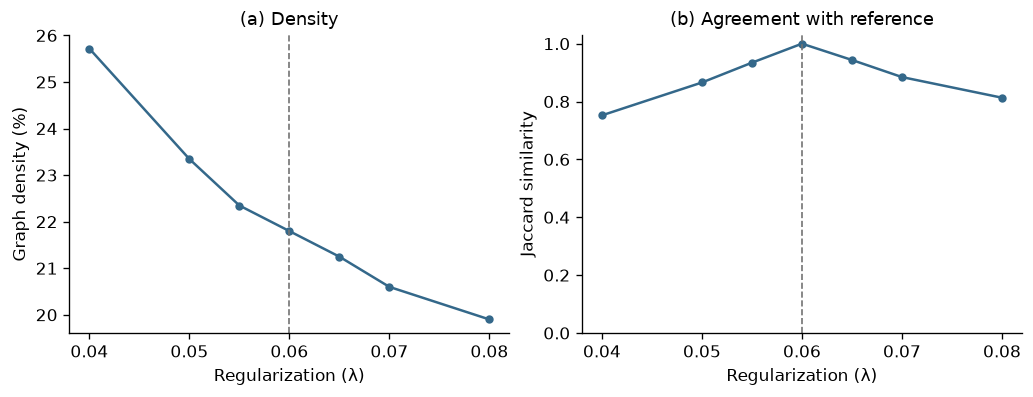

In [4]:
grid_metrics = pd.DataFrame([
    {'lambda': value, **graph_metrics(edges)}
    for value, edges in zip(LAMBDA_GRID, grid_masks)
])
grid_table = grid_metrics.assign(density=100 * grid_metrics.density).rename(columns={
    'lambda': 'λ', 'edges': 'Edges', 'density': 'Density (%)',
    'components': 'Components', 'jaccard': 'Jaccard',
})
display(grid_table.style.format({
    'λ': '{:.3f}', 'Edges': '{:.0f}', 'Density (%)': '{:.2f}',
    'Components': '{:.0f}', 'Jaccard': '{:.3f}',
}).hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.2), layout='constrained')
axes[0].plot(LAMBDA_GRID, 100 * grid_metrics.density, 'o-', color=BLUE, markersize=4)
axes[0].set(xlabel='Regularization (λ)', ylabel='Graph density (%)', title='(a) Density')
axes[1].plot(LAMBDA_GRID, grid_metrics.jaccard, 'o-', color=BLUE, markersize=4)
axes[1].set(
    xlabel='Regularization (λ)', ylabel='Jaccard similarity',
    title='(b) Agreement with reference', ylim=(0, 1.03),
)
for ax in axes:
    ax.axvline(LAMBDA, color='0.45', linestyle='--', linewidth=1)
    ax.set_xticks([0.04, 0.05, 0.06, 0.07, 0.08])
plt.show()

## Subject subsampling

Each of 1,000 independently drawn subsamples contains 64 distinct controls sampled uniformly without replacement from the 75 included controls (85.33%; seed 20260930).

,2.5th percentile,Median,97.5th percentile
Edges,854,885,922
Density (%),21.32,22.10,23.02
Components,1,1,1
Jaccard,0.668,0.733,0.792


Pair set,Mean frequency,Median frequency
Reference edges,0.851,0.951
Absent from reference,0.046,0.001


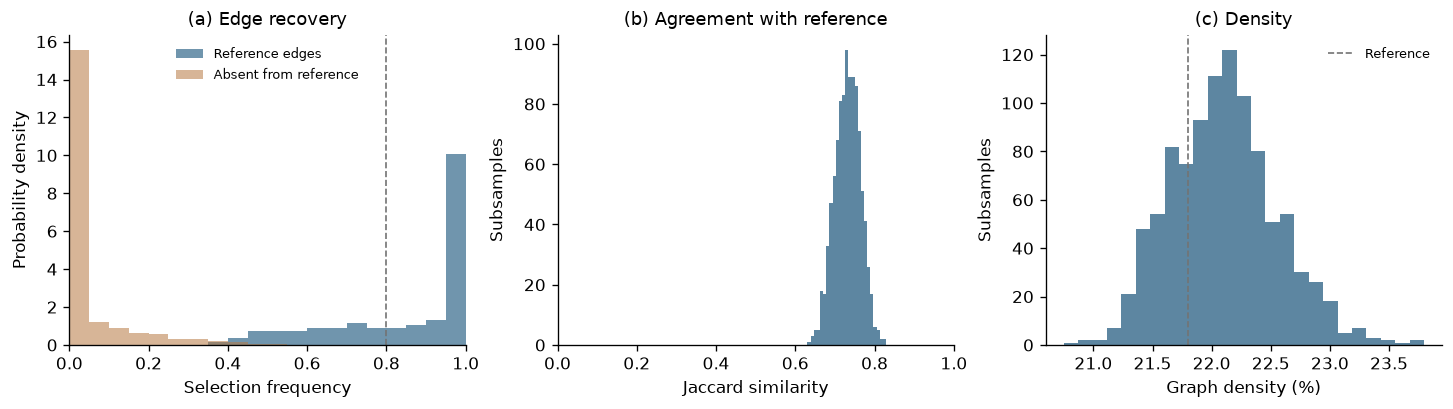

In [5]:
subsample_metrics = pd.DataFrame([graph_metrics(edges) for edges in subsample_masks])
subsample_summary = subsample_metrics.quantile([0.025, 0.5, 0.975]).T
subsample_table = subsample_summary.copy()
subsample_table.loc['density'] *= 100
subsample_table.index = ['Edges', 'Density (%)', 'Components', 'Jaccard']
subsample_table.columns = ['2.5th percentile', 'Median', '97.5th percentile']
display(
    subsample_table.style.format('{:.3f}')
    .format('{:.0f}', subset=pd.IndexSlice[['Edges', 'Components'], :])
    .format('{:.2f}', subset=pd.IndexSlice[['Density (%)'], :])
)

frequencies = subsample_masks.mean(axis=0)
edge_frequencies = pd.DataFrame({
    'roi_1': roi_names[u], 'roi_2': roi_names[v],
    'reference': reference_edges, 'frequency': frequencies,
})
frequency_summary = pd.DataFrame([
    {
        'Pair set': label,
        'Mean frequency': frequencies[mask].mean(),
        'Median frequency': np.median(frequencies[mask]),
    }
    for label, mask in [
        ('Reference edges', reference_edges), ('Absent from reference', ~reference_edges),
    ]
])
display(frequency_summary.style.format({
    'Mean frequency': '{:.3f}', 'Median frequency': '{:.3f}',
}).hide(axis='index'))

fig, axes = plt.subplots(1, 3, figsize=(12, 3.3), layout='constrained')
bins = np.linspace(0, 1, 21)
axes[0].hist(
    frequencies[reference_edges], bins=bins, density=True,
    alpha=0.7, color=BLUE, label='Reference edges',
)
axes[0].hist(
    frequencies[~reference_edges], bins=bins, density=True,
    alpha=0.55, color=ORANGE, label='Absent from reference',
)
axes[0].axvline(CONSENSUS_THRESHOLD, color='0.45', linestyle='--', linewidth=1)
axes[0].set(
    xlabel='Selection frequency', ylabel='Probability density',
    title='(a) Edge recovery', xlim=(0, 1),
)
axes[0].legend(fontsize=8, frameon=False)
axes[1].hist(subsample_metrics.jaccard, bins=25, color=BLUE, alpha=0.8)
axes[1].set(
    xlabel='Jaccard similarity', ylabel='Subsamples',
    title='(b) Agreement with reference', xlim=(0, 1),
)
axes[2].hist(100 * subsample_metrics.density, bins=25, color=BLUE, alpha=0.8)
axes[2].axvline(
    100 * reference_metrics['density'], color='0.45',
    linestyle='--', linewidth=1, label='Reference',
)
axes[2].set(xlabel='Graph density (%)', ylabel='Subsamples', title='(c) Density')
axes[2].legend(fontsize=8, frameon=False)
plt.show()

## Edge stability and consensus

Selection frequency is the fraction of subsampled graphs containing an edge. Reference-edge recovery is evaluated at four thresholds. The consensus includes all ROI pairs with selection frequency ≥0.80 and retains all 90 ROIs, including any isolated regions.

In [6]:
stability = pd.DataFrame([
    {
        'threshold': threshold,
        'reference_edges': int(np.count_nonzero(reference_edges & (frequencies >= threshold))),
        'reference_percentage': 100 * np.count_nonzero(
            reference_edges & (frequencies >= threshold)
        ) / reference_edges.sum(),
    }
    for threshold in FREQUENCY_THRESHOLDS
])
stability_table = stability.rename(columns={
    'threshold': 'Frequency ≥', 'reference_edges': 'Reference edges',
    'reference_percentage': 'Reference edges (%)',
})
display(stability_table.style.format({
    'Frequency ≥': '{:.2f}', 'Reference edges': '{:.0f}',
    'Reference edges (%)': '{:.2f}',
}).hide(axis='index'))

consensus_edges = frequencies >= CONSENSUS_THRESHOLD
consensus_matrix = np.zeros((p, p), dtype=np.uint8)
consensus_matrix[u, v] = consensus_edges
consensus_matrix[v, u] = consensus_edges
consensus_metrics = pd.DataFrame([
    {'topology': 'Reference', **reference_metrics},
    {'topology': 'Consensus ≥0.80', **graph_metrics(consensus_edges)},
])
consensus_table = consensus_metrics.assign(
    density=100 * consensus_metrics.density,
).rename(columns={
    'topology': 'Topology', 'edges': 'Edges', 'density': 'Density (%)',
    'components': 'Components', 'jaccard': 'Jaccard',
})
display(consensus_table.style.format({
    'Edges': '{:.0f}', 'Density (%)': '{:.2f}',
    'Components': '{:.0f}', 'Jaccard': '{:.3f}',
}).hide(axis='index'))

Frequency ≥,Reference edges,Reference edges (%)
0.50,818,93.70
0.70,675,77.32
0.80,583,66.78
0.90,496,56.82


Topology,Edges,Density (%),Components,Jaccard
Reference,873,21.80,1,1.000
Consensus ≥0.80,583,14.56,1,0.668


## Interpretation

Frequency precision is assessed by comparing the first 500 subsamples with all 1,000. The Monte Carlo standard error of a frequency $f$ is $\sqrt{f(1-f)/1000}$; it measures simulation precision conditional on the included controls.

In [7]:
half_frequencies = subsample_masks[:REPETITIONS // 2].mean(axis=0)
frequency_delta = np.abs(half_frequencies - frequencies)
monte_carlo_se = np.sqrt(frequencies * (1 - frequencies) / REPETITIONS)
near_consensus_threshold = int(np.count_nonzero(
    reference_edges & (np.abs(frequencies - CONSENSUS_THRESHOLD) <= 1.96 * monte_carlo_se)
))

assert np.all((frequencies >= 0) & (frequencies <= 1))
assert np.isclose(frequencies.sum(), subsample_metrics.edges.mean())
assert subsample_metrics.density.between(0, 1).all()
assert subsample_metrics.jaccard.between(0, 1).all()
assert (subsample_metrics.components >= 1).all()
assert np.array_equal(consensus_matrix, consensus_matrix.T)
assert np.all(np.diag(consensus_matrix) == 0)
assert consensus_matrix.sum() == 2 * consensus_edges.sum()
assert stability.reference_edges.is_monotonic_decreasing

local = grid_metrics.loc[grid_metrics['lambda'].isin([0.055, 0.065]), 'jaccard']
wide = grid_metrics.loc[grid_metrics['lambda'].isin([0.040, 0.080]), 'jaccard']
q = subsample_summary
consensus = consensus_metrics.iloc[1]
retained_edges = int(np.count_nonzero(consensus_edges & reference_edges))
added_edges = int(np.count_nonzero(consensus_edges & ~reference_edges))
connected_subsamples = int((subsample_metrics.components == 1).sum())

display(Markdown(
    f"Jaccard similarity was **{local.min():.3f}–{local.max():.3f}** for ±8.3% "
    f"changes in λ and {wide.min():.3f}–{wide.max():.3f} for ±33.3% changes. "
    f"Across the seven λ values, density ranged from {100 * grid_metrics.density.min():.2f}% "
    f"to {100 * grid_metrics.density.max():.2f}%; "
    f"{int((grid_metrics.components == 1).sum())}/7 graphs remained connected.\n\n"
    f"Across control subsamples, median Jaccard similarity was **{q.loc['jaccard', 0.5]:.3f}** "
    f"(2.5th–97.5th percentiles: {q.loc['jaccard', 0.025]:.3f}–{q.loc['jaccard', 0.975]:.3f}). "
    f"Median density was {100 * q.loc['density', 0.5]:.2f}% "
    f"({100 * q.loc['density', 0.025]:.2f}–{100 * q.loc['density', 0.975]:.2f}%), "
    f"and {connected_subsamples:,}/{REPETITIONS:,} graphs remained connected.\n\n"
    f"Reference edges had a median selection frequency of "
    f"{np.median(frequencies[reference_edges]):.3f}. The ≥0.80 consensus contained "
    f"**{int(consensus.edges)} edges**, retaining "
    f"{100 * retained_edges / reference_edges.sum():.2f}% of reference edges and adding "
    f"{added_edges} connections. Its density was {100 * consensus.density:.2f}%, "
    f"with {int(consensus.components)} connected component.\n\n"
    f"The mean absolute change in reference-edge frequencies between 500 and 1,000 "
    f"subsamples was {frequency_delta[reference_edges].mean():.4f}. The maximum possible "
    f"Monte Carlo standard error was {np.sqrt(0.25 / REPETITIONS):.4f}; "
    f"{near_consensus_threshold} reference edges fell within 1.96 estimated Monte Carlo "
    f"standard errors of the 0.80 threshold, so membership near this cutoff is less precise."
))

Jaccard similarity was **0.934–0.944** for ±8.3% changes in λ and 0.752–0.813 for ±33.3% changes. Across the seven λ values, density ranged from 19.90% to 25.72%; 7/7 graphs remained connected.

Across control subsamples, median Jaccard similarity was **0.733** (2.5th–97.5th percentiles: 0.668–0.792). Median density was 22.10% (21.32–23.02%), and 1,000/1,000 graphs remained connected.

Reference edges had a median selection frequency of 0.951. The ≥0.80 consensus contained **583 edges**, retaining 66.78% of reference edges and adding 0 connections. Its density was 14.56%, with 1 connected component.

The mean absolute change in reference-edge frequencies between 500 and 1,000 subsamples was 0.0052. The maximum possible Monte Carlo standard error was 0.0158; 43 reference edges fell within 1.96 estimated Monte Carlo standard errors of the 0.80 threshold, so membership near this cutoff is less precise.